# Out of Sample Validation
This notebook evaluates whether the pairs trading strategy generalizes out of sample.

Candidate pairs and regression directions are selected using only the training data, then tested on the test data.

The goal here is to avoid look-ahead bias and assess whether the strategy has evidence of predictive value beyond the data used for selection. 

In [3]:
# imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/nordi/Desktop/pairs-trading-backtest')

In [4]:
# import pairs-trading
from src.data import download_prices
from src.pairs_trading import (
    compute_simple_returns,
    rank_pairs_by_correlation,
    compute_cumulative_returns,
    run_dynamic_beta_backtest,
)

## Data
The strategy is tested on a small universe of US ETFs. Daily adjusted close prices are downloaded, then daily simple returns are used for correlation-based pair screening.

In [6]:
# data
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

start = "2015-01-01"
end = "2026-01-01"

prices = download_prices(
    tickers=tickers,
    start=start,
    end=end,
)

returns = compute_simple_returns(prices)

print("prices:", prices.shape)
print("returns:", returns.shape)

prices.head()

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
prices: (2766, 15)
returns: (2765, 15)


,SPY,QQQ,IWM,XLK,XLF,XLE,XLV,XLY,XLP,XLI,XLU,TLT,HYG,LQD,GLD
Date,,,,,,,,,,,,,,,
2015-01-02,169.687866,94.561134,102.543121,18.062738,16.217979,25.365137,56.807293,31.573736,35.618256,46.097977,16.406504,92.659241,48.571236,80.124290,114.080002
2015-01-05,166.623337,93.174057,101.172203,17.786995,15.876958,24.315830,56.517605,30.969851,35.367790,45.021183,16.205923,94.114807,48.121277,80.451912,115.800003
2015-01-06,165.053925,91.924744,99.421921,17.572544,15.634314,23.958616,56.327225,30.661303,35.323582,44.466480,16.216291,95.810455,47.936970,80.779549,117.120003
2015-01-07,167.110687,93.109741,100.646263,17.721348,15.798264,24.009644,57.651592,31.146170,35.927650,44.800945,16.375380,95.621239,48.235123,80.886536,116.430000
2015-01-08,170.076004,94.891846,102.353447,18.110880,16.034355,24.548655,58.636589,31.613401,36.472797,45.698257,16.489502,94.354973,48.598339,80.625763,115.940002


## Train/Test Split
The data is split into training and test sets.

We'll use the period 2015-2019 for the training set, and 2020-2025 for the test set.

The training set is used to selected candidate pairs and regression directions. The test period is used only for out-of-sample evaluation.

In [8]:
# training set
train_start = "2015-01-01"
train_end = "2023-12-31"
train_prices = prices.loc[train_start:train_end]
train_returns = compute_simple_returns(train_prices)

# test set
test_start = "2024-01-01"
test_end = "2026-01-01"
test_prices = prices.loc[test_start:test_end]
test_returns = compute_simple_returns(test_prices)

print("train prices:", train_prices.shape)
print("test prices:", test_prices.shape)

train prices: (1258, 15)
test prices: (1508, 15)


## Pair Selection

Candidate pairs are selected using daily return correlations in the training set only. This avoids using future information from the test period when selecting which pairs to trade.

Correlation is used as a first-pass screening tool. High correlation does not guarantee that the spread is mean-reverting, but it identifies pairs whose short-run movements are similar.

In [10]:
train_ranked_pairs = rank_pairs_by_correlation(train_returns)

top_train_pairs = train_ranked_pairs.head(10)

top_train_pairs.round(4)

,ticker_1,ticker_2,correlation
15,QQQ,XLK,0.9729
0,SPY,QQQ,0.9272
2,SPY,XLK,0.9192
6,SPY,XLY,0.9121
8,SPY,XLI,0.9014
19,QQQ,XLY,0.8889
1,SPY,IWM,0.8711
3,SPY,XLF,0.8537
42,XLK,XLY,0.8487
100,TLT,LQD,0.8429


## Strategy Parameters

The strategy uses the dynamic-beta version developed in earlier notebooks. The hedge ratio is estimated using a rolling one-year window, and the spread is standardized using a rolling z-score.

The parameter values below come from the single-pair sensitivity analysis. They are not re-optimized in the test period.

In [12]:
# baseline parameters
hedge_window = 252
zscore_window = 120
entry_threshold = 2.0
exit_threshold = 0.5
transaction_cost_bps = 5.0

## Directed Pair Selection Using Training Data

For each candidate pair, both regression directions are tested in the training period:

$$ Y_t = \alpha_t + \beta_t X_t + \varepsilon_t $$

The direction matters because the regression residual error, and therefore the spread, changes depending on which ETF is treated as $Y$ and which is treated as $X$.

Directed pairs are ranked by training-period Sharpe ratio.

In [14]:
train_directional_results = []

for _, row in top_train_pairs.iterrows():
    ticker_a = row["ticker_1"]
    ticker_b = row["ticker_2"]
    train_correlation = row["correlation"]

    directions = [
        (ticker_a, ticker_b),
        (ticker_b, ticker_a)
    ]

    for ticker_y, ticker_x in directions:
        print(f"Running train Y={ticker_y}/X={ticker_x}...")
        
        try:
            metrics = run_dynamic_beta_backtest(
                prices=prices,
                ticker_y=ticker_y,
                ticker_x=ticker_x,
                hedge_window=hedge_window,
                zscore_window=zscore_window,
                entry_threshold=entry_threshold,
                exit_threshold=exit_threshold,
                transaction_cost_bps=transaction_cost_bps,
                evaluation_start=None,
                evaluation_end=train_end,
            )

            metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
            metrics["ticker_y"] = ticker_y
            metrics["ticker_x"] = ticker_x
            metrics["train_correlation"] = train_correlation
            train_directional_results.append(metrics)

        except Exception as e:
            print(f"Failed on train Y={ticker_y}/X={ticker_x}: {e}")


Running train Y=QQQ/X=XLK...
Running train Y=XLK/X=QQQ...
Running train Y=SPY/X=QQQ...
Running train Y=QQQ/X=SPY...
Running train Y=SPY/X=XLK...
Running train Y=XLK/X=SPY...
Running train Y=SPY/X=XLY...
Running train Y=XLY/X=SPY...
Running train Y=SPY/X=XLI...
Running train Y=XLI/X=SPY...
Running train Y=QQQ/X=XLY...
Running train Y=XLY/X=QQQ...
Running train Y=SPY/X=IWM...
Running train Y=IWM/X=SPY...
Running train Y=SPY/X=XLF...
Running train Y=XLF/X=SPY...
Running train Y=XLK/X=XLY...
Running train Y=XLY/X=XLK...
Running train Y=TLT/X=LQD...
Running train Y=LQD/X=TLT...


In [15]:
# format and sort results
cols = [
    "pair",
    "ticker_y",
    "ticker_x",
    "train_correlation",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

train_directional_df = pd.DataFrame(train_directional_results)
train_directional_df = train_directional_df[cols]

train_directional_df.sort_values("sharpe_ratio", ascending=False).round(4)

,pair,ticker_y,ticker_x,train_correlation,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
9,Y=XLI/X=SPY,XLI,SPY,0.9014,0.0866,0.0239,0.0200,1.1910,-0.0179,14,0.8571,18.3571,0.2743
8,Y=SPY/X=XLI,SPY,XLI,0.9014,0.0659,0.0183,0.0224,0.8230,-0.0236,14,0.9286,21.2143,0.3194
4,Y=SPY/X=XLK,SPY,XLK,0.9192,0.0467,0.0131,0.0177,0.7430,-0.0215,11,0.8182,25.8182,0.3081
5,Y=XLK/X=SPY,XLK,SPY,0.9192,0.0434,0.0122,0.0169,0.7229,-0.0190,10,0.9000,26.5000,0.2878
1,Y=XLK/X=QQQ,XLK,QQQ,0.9729,0.0153,0.0043,0.0131,0.3355,-0.0301,11,0.7273,36.2727,0.4966
12,Y=SPY/X=IWM,SPY,IWM,0.8711,0.0301,0.0085,0.0268,0.3278,-0.0396,11,0.6364,35.0000,0.4673
2,Y=SPY/X=QQQ,SPY,QQQ,0.9272,0.0118,0.0034,0.0163,0.2134,-0.0233,10,0.6000,27.0000,0.2935
3,Y=QQQ/X=SPY,QQQ,SPY,0.9272,0.0111,0.0031,0.0153,0.2120,-0.0214,9,0.7778,30.4444,0.2991
11,Y=XLY/X=QQQ,XLY,QQQ,0.8889,0.0189,0.0053,0.0268,0.2115,-0.0592,17,0.8824,20.4118,0.4255
17,Y=XLY/X=XLK,XLY,XLK,0.8487,0.0207,0.0058,0.0313,0.2015,-0.0807,15,0.8000,23.6667,0.3837


## Selected Directed Pairs

The top directed pairs are selected using training set performance only. These choices are fixed before evaluating the test set.

In [17]:
n_selected_pairs = 5

selected_directed_pairs = (
    train_directional_df
    .sort_values("sharpe_ratio", ascending=False)
    .head(n_selected_pairs)
    .copy()
)

selected_directed_pairs[
    ["pair", "train_correlation", "total_return", "sharpe_ratio", "n_trades"]
].round(4)

,pair,train_correlation,total_return,sharpe_ratio,n_trades
9,Y=XLI/X=SPY,0.9014,0.0866,1.1910,14
8,Y=SPY/X=XLI,0.9014,0.0659,0.8230,14
4,Y=SPY/X=XLK,0.9192,0.0467,0.7430,11
5,Y=XLK/X=SPY,0.9192,0.0434,0.7229,10
1,Y=XLK/X=QQQ,0.9729,0.0153,0.3355,11


## Out of Sample Evaluation

The selected directed pairs are now evaluated from 2020 onward. No pair selection, direction selection, or parameter tuning is performed using the test period.

In [19]:
selected_oos_results = []

for _, row in selected_directed_pairs.iterrows():
    ticker_y = row["ticker_y"]
    ticker_x = row["ticker_x"]
    train_correlation = row["train_correlation"]

    print(f"Running OOS Y={ticker_y}/X={ticker_x}...")

    metrics = run_dynamic_beta_backtest(
        prices=prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        hedge_window=hedge_window,
        zscore_window=zscore_window,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold,
        transaction_cost_bps=transaction_cost_bps,
        evaluation_start=test_start,
        evaluation_end=test_end,
    )

    metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
    metrics["ticker_y"] = ticker_y
    metrics["ticker_x"] = ticker_x
    metrics["train_correlation"] = train_correlation

    selected_oos_results.append(metrics)

Running OOS Y=XLI/X=SPY...
Running OOS Y=SPY/X=XLI...
Running OOS Y=SPY/X=XLK...
Running OOS Y=XLK/X=SPY...
Running OOS Y=XLK/X=QQQ...


In [20]:
# format
selected_oos_df = pd.DataFrame(selected_oos_results)
selected_oos_df = selected_oos_df[cols]

selected_oos_df.sort_values("sharpe_ratio", ascending=False).round(4)

,pair,ticker_y,ticker_x,train_correlation,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
4,Y=XLK/X=QQQ,XLK,QQQ,0.9729,0.0645,0.0105,0.0216,0.4955,-0.0377,26,0.8077,22.3462,0.3680
2,Y=SPY/X=XLK,SPY,XLK,0.9192,0.0841,0.0136,0.0327,0.4289,-0.0912,23,0.8261,23.1304,0.3375
1,Y=SPY/X=XLI,SPY,XLI,0.9014,-0.0179,-0.0030,0.0357,-0.0668,-0.0905,18,0.6111,32.8889,0.3806
3,Y=XLK/X=SPY,XLK,SPY,0.9192,-0.0485,-0.0083,0.0370,-0.2061,-0.1417,20,0.7000,36.0500,0.4728
0,Y=XLI/X=SPY,XLI,SPY,0.9014,-0.1100,-0.0193,0.0377,-0.4980,-0.1363,15,0.5333,41.7333,0.4052


## Train vs. Test Comparison

This table compares training set performance versus test (out of sample) performance. A large drop in Sharpe ratio would indicate that a pair looked primising in training but that the model did not generalize well.

In [22]:
train_selected_summary = selected_directed_pairs[
    ["pair", "ticker_y", "ticker_x", "train_correlation", "total_return", "sharpe_ratio", "n_trades"]
].copy()

train_selected_summary = train_selected_summary.rename(
    columns={
        "total_return": "train_total_return",
        "sharpe_ratio": "train_sharpe",
        "n_trades": "train_n_trades",
    }
)

oos_selected_summary = selected_oos_df[
    ["pair", "total_return", "sharpe_ratio", "n_trades"]
].copy()

oos_selected_summary = oos_selected_summary.rename(
    columns={
        "total_return": "oos_total_return",
        "sharpe_ratio": "oos_sharpe",
        "n_trades": "oos_n_trades",
    }
)

generalization = train_selected_summary.merge(
    oos_selected_summary,
    on="pair",
    how="inner",
)

generalization["sharpe_change"] = (
    generalization["oos_sharpe"] - generalization["train_sharpe"]
)

generalization[
    [
        "pair",
        "train_correlation",
        "train_total_return",
        "oos_total_return",
        "train_sharpe",
        "oos_sharpe",
        "sharpe_change",
        "train_n_trades",
        "oos_n_trades",
    ]
].sort_values("oos_sharpe", ascending=False).round(4)

,pair,train_correlation,train_total_return,oos_total_return,train_sharpe,oos_sharpe,sharpe_change,train_n_trades,oos_n_trades
4,Y=XLK/X=QQQ,0.9729,0.0153,0.0645,0.3355,0.4955,0.1601,11,26
2,Y=SPY/X=XLK,0.9192,0.0467,0.0841,0.7430,0.4289,-0.3141,11,23
1,Y=SPY/X=XLI,0.9014,0.0659,-0.0179,0.8230,-0.0668,-0.8897,14,18
3,Y=XLK/X=SPY,0.9192,0.0434,-0.0485,0.7229,-0.2061,-0.9290,10,20
0,Y=XLI/X=SPY,0.9014,0.0866,-0.1100,1.1910,-0.4980,-1.6890,14,15


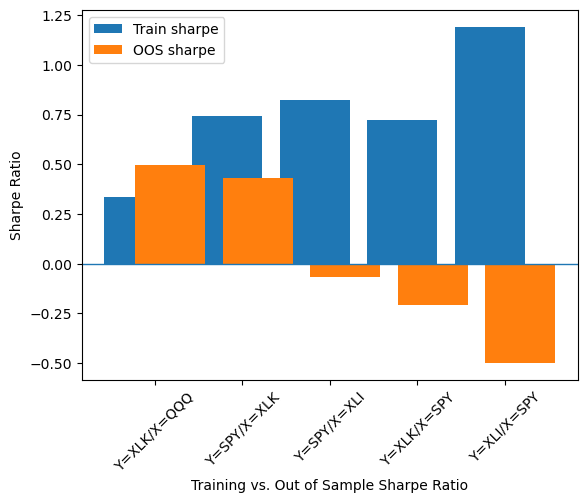

In [23]:
# plot train versus test sharpe
plot_df = generalization.sort_values("oos_sharpe", ascending=False)

x = np.arange(len(plot_df))
width = 0.35

plt.bar(x-width/2, plot_df["train_sharpe"], label="Train sharpe")
plt.bar(x+width/2, plot_df["oos_sharpe"], label="OOS sharpe")

plt.axhline(0, linewidth=1)
plt.xticks(x, plot_df["pair"], rotation=45)
plt.ylabel("Sharpe Ratio")
plt.xlabel("Training vs. Out of Sample Sharpe Ratio")
plt.legend()
plt.show()